In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar os dados
orders = pd.read_csv('C:\\Users\\prisc\\Desktop\\data_analytics_fiap-01100826\\data\\raw\\olist_orders_dataset.csv')
order_items = pd.read_csv('C:\\Users\\prisc\\Desktop\\data_analytics_fiap-01100826\\data\\raw\\olist_order_items_dataset.csv')

# Converter a coluna de data para datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Extrair o mês e ano
orders['mes_ano'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Filtrar apenas pedidos entregues
orders_entregues = orders[orders['order_status'] == 'delivered']

# Agregar a receita por mês
receita_mensal = order_items.groupby(order_items.index.map(lambda x: orders.loc[x, 'mes_ano'] if x < len(orders) else None))['price'].sum()

# Forma alternativa (mais correta):
# Juntar os dados
dados = orders_entregues[['order_id', 'mes_ano']].merge(order_items, on='order_id')

# Agrupar por mês
receita_por_mes = dados.groupby('mes_ano')['price'].sum().reset_index()
receita_por_mes.columns = ['mes_ano', 'receita']

print(receita_por_mes)


    mes_ano    receita
0   2016-09     134.97
1   2016-10   40325.11
2   2016-12      10.90
3   2017-01  111798.36
4   2017-02  234223.40
5   2017-03  359198.85
6   2017-04  340669.68
7   2017-05  489338.25
8   2017-06  421923.37
9   2017-07  481604.52
10  2017-08  554699.70
11  2017-09  607399.67
12  2017-10  648247.65
13  2017-11  987765.37
14  2017-12  726033.19
15  2018-01  924645.00
16  2018-02  826437.13
17  2018-03  953356.25
18  2018-04  973534.09
19  2018-05  977544.69
20  2018-06  856077.86
21  2018-07  867953.46
22  2018-08  838576.64


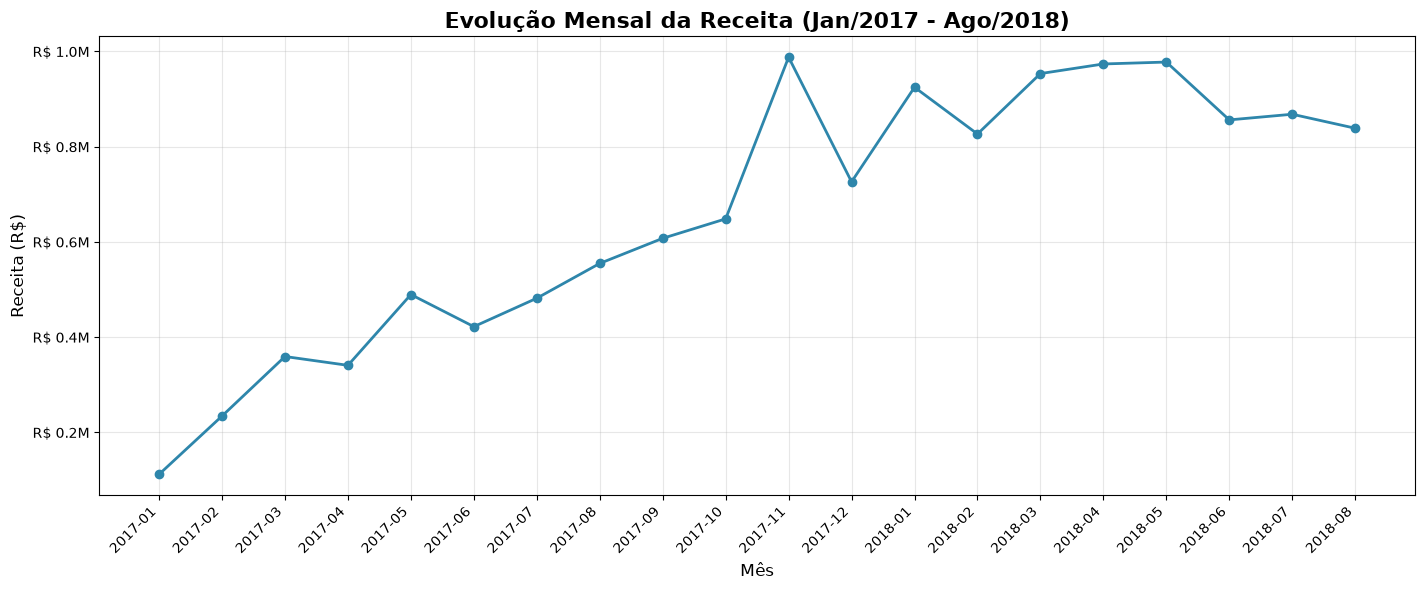

In [3]:
# Filtrar dados entre janeiro de 2017 e agosto de 2018
receita_2017_2018 = receita_por_mes[
    (receita_por_mes['mes_ano'] >= '2017-01') & 
    (receita_por_mes['mes_ano'] <= '2018-08')
].copy()

# Converter para string para plotar melhor
receita_2017_2018['mes_ano_str'] = receita_por_mes['mes_ano'].astype(str)

# Criar o gráfico
plt.figure(figsize=(14, 6))
plt.plot(receita_2017_2018['mes_ano_str'], receita_2017_2018['receita'], marker='o', linewidth=2, markersize=6, color='#2E86AB')

plt.title('Evolução Mensal da Receita (Jan/2017 - Ago/2018)', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Formatar o eixo Y para mostrar valores em milhões
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M'))

plt.show()

In [4]:
# ========== CARREGAMENTO DE DADOS ==========
products = pd.read_csv('C:\\Users\\prisc\\Desktop\\data_analytics_fiap-01100826\\data\\raw\\olist_products_dataset.csv')
product_translation = pd.read_csv('C:\\Users\\prisc\\Desktop\\data_analytics_fiap-01100826\\data\\raw\\product_category_name_translation.csv')

# ========== PRODUTOS TOP PERFORMERS ==========
print("=" * 80)
print("TOP 15 PRODUTOS COM MAIOR RECEITA")
print("=" * 80)

# Agregar receita por produto
receita_por_produto = order_items.groupby('product_id').agg({
    'price': 'sum',
    'product_id': 'count'  # quantidade de vendas
}).rename(columns={'price': 'receita', 'product_id': 'quantidade_vendas'}).reset_index()

# Juntar com informações de categoria
receita_por_produto = receita_por_produto.merge(products[['product_id', 'product_category_name']], on='product_id')
receita_por_produto = receita_por_produto.merge(product_translation, on='product_category_name', how='left')

# Ordenar por receita
receita_por_produto = receita_por_produto.sort_values('receita', ascending=False)

# Exibir top 15
top_produtos = receita_por_produto.head(15)[['product_id', 'product_category_name', 'product_category_name_english', 'receita', 'quantidade_vendas']].copy()
top_produtos['receita'] = top_produtos['receita'].apply(lambda x: f'R$ {x:,.2f}')
print(top_produtos.to_string(index=False))

# ========== SELLERS TOP PERFORMERS ==========
print("\n" + "=" * 80)
print("TOP 15 SELLERS COM MAIOR RECEITA")
print("=" * 80)

# Juntar sellers com receita
top_sellers = receita_por_seller.head(15)[['seller_id', 'receita', 'percentual']].copy()
top_sellers['receita'] = top_sellers['receita'].apply(lambda x: f'R$ {x:,.2f}')
print(top_sellers.to_string(index=False))

# ========== SALVAR PARA OS GRÁFICOS ==========
# Dados para gráfico de produtos (top 10)
top_produtos_grafico = receita_por_produto.head(10).copy()

# Dados para gráfico de sellers (top 10)
top_sellers_grafico = receita_por_seller.head(10).copy()


TOP 15 PRODUTOS COM MAIOR RECEITA
                      product_id  product_category_name product_category_name_english      receita  quantidade_vendas
bb50f2e236e5eea0100680137654686c           beleza_saude                 health_beauty R$ 63,885.00                195
6cdd53843498f92890544667809f1595           beleza_saude                 health_beauty R$ 54,730.20                156
d6160fb7873f184099d9bc95e30376af                    pcs                     computers R$ 48,899.34                 35
d1c427060a0f73f6b889a5c7c61f2ac4 informatica_acessorios         computers_accessories R$ 47,214.51                343
99a4788cb24856965c36a24e339b6058        cama_mesa_banho                bed_bath_table R$ 43,025.56                488
3dd2a17168ec895c781a9191c1e95ad7 informatica_acessorios         computers_accessories R$ 41,082.60                274
25c38557cf793876c5abdd5931f922db                  bebes                          baby R$ 38,907.32                 38
5f504b3a1c75b73d6151be

NameError: name 'receita_por_seller' is not defined

In [5]:
# Juntar orders com order_items e sellers
sellers = pd.read_csv('C:\\Users\\prisc\\Desktop\\data_analytics_fiap-01100826\\data\\raw\\olist_sellers_dataset.csv')

# Agregar a receita por seller
receita_por_seller = order_items.groupby('seller_id')['price'].sum().reset_index()
receita_por_seller.columns = ['seller_id', 'receita']

# Ordenar pela receita (maior para menor)
receita_por_seller = receita_por_seller.sort_values('receita', ascending=False)

# Calcular a receita total
receita_total = receita_por_seller['receita'].sum()

# Calcular a porcentagem de cada seller
receita_por_seller['percentual'] = (receita_por_seller['receita'] / receita_total * 100).round(2)

# Calcular percentual acumulado
receita_por_seller['percentual_acumulado'] = receita_por_seller['percentual'].cumsum()

# Mostrar os top 10 sellers
print("TOP 10 SELLERS POR RECEITA")
print("=" * 70)
print(receita_por_seller.head(10)[['seller_id', 'receita', 'percentual', 'percentual_acumulado']])

TOP 10 SELLERS POR RECEITA
                             seller_id    receita  percentual  \
857   4869f7a5dfa277a7dca6462dcf3b52b2  229472.63        1.69   
1013  53243585a1d6dc2643021fd1853d8905  222776.05        1.64   
881   4a3ca9315b744ce9f8e9374361493884  200472.92        1.47   
3024  fa1c13f2614d7b5c4749cbc52fecda94  194042.03        1.43   
1535  7c67e1448b00f6e969d365cea6b010ab  187923.89        1.38   
1560  7e93a43ef30c4f03f38b393420bc753a  176431.87        1.30   
2643  da8622b14eb17ae2831f4ac5b9dab84a  160236.57        1.18   
1505  7a67c85e85bb2ce8582c35f2203ad736  141745.53        1.04   
192   1025f0e2d44d7041d6cf58b6550e0bfa  138968.55        1.02   
1824  955fee9216a65b617aa5c0531780ce60  135171.70        0.99   

      percentual_acumulado  
857                   1.69  
1013                  3.33  
881                   4.80  
3024                  6.23  
1535                  7.61  
1560                  8.91  
2643                 10.09  
1505                 11.1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ========== CONFIGURAÇÃO PROFISSIONAL ==========
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Análise de Desempenho: Produtos vs Sellers', fontsize=18, fontweight='bold', y=0.98)

# ========== GRÁFICO 1: TOP 10 PRODUTOS ==========
produtos_nomes = top_produtos_grafico['product_category_name_english'].fillna(top_produtos_grafico['product_category_name'])
cores_produtos = ['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', 
                  '#aec7e8', '#aec7e8', '#aec7e8', '#aec7e8', '#aec7e8']

barras1 = ax1.barh(range(len(produtos_nomes)), top_produtos_grafico['receita'], 
                    color=cores_produtos, edgecolor='black', linewidth=0.7)

# Adicionar valores nas barras
for i, barra in enumerate(barras1):
    width = barra.get_width()
    ax1.text(width, barra.get_y() + barra.get_height()/2, 
             f' R$ {width/1e6:.2f}M', 
             ha='left', va='center', fontsize=9, fontweight='bold')

ax1.set_yticks(range(len(produtos_nomes)))
ax1.set_yticklabels(produtos_nomes, fontsize=11)
ax1.set_xlabel('Receita (R$)', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Categorias de Produtos', fontsize=14, fontweight='bold', pad=20)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.4, linestyle='--')
ax1.set_axisbelow(True)

# Remover spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Formatar eixo X
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M'))

# ========== GRÁFICO 2: TOP 10 SELLERS ==========
sellers_ids = top_sellers_grafico['seller_id'].values
cores_sellers = ['#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c',
                 '#98df8a', '#98df8a', '#98df8a', '#98df8a', '#98df8a']

barras2 = ax2.barh(range(len(sellers_ids)), top_sellers_grafico['receita'], 
                    color=cores_sellers, edgecolor='black', linewidth=0.7)

# Adicionar valores nas barras
for i, barra in enumerate(barras2):
    width = barra.get_width()
    ax2.text(width, barra.get_y() + barra.get_height()/2, 
             f' R$ {width/1e6:.2f}M', 
             ha='left', va='center', fontsize=9, fontweight='bold')

ax2.set_yticks(range(len(sellers_ids)))
ax2.set_yticklabels([f"Seller {i+1}" for i in range(len(sellers_ids))], fontsize=11)
ax2.set_xlabel('Receita (R$)', fontsize=12, fontweight='bold')
ax2.set_title('Top 10 Sellers', fontsize=14, fontweight='bold', pad=20)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.4, linestyle='--')
ax2.set_axisbelow(True)

# Remover spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Formatar eixo X
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M'))

# Ajustes finais
plt.tight_layout()
plt.show()

# ========== RESUMO DE CONCENTRAÇÃO ==========
print("\n")

In [4]:
print(top_produtos_grafico.head())
print(top_sellers_grafico.head())

NameError: name 'top_produtos_grafico' is not defined